<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/04_movie_intel_community_detection_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Community Detection and Summarization

## Objective
Build a reusable community detection pipeline for a Movie Knowledge Graph using Neo4j Graph Data Science (GDS) and an LLM.

### Workflow
1. Connect to Neo4j
2. Project graph into GDS
3. Run Leiden
4. Retrieve communities
5. Summarize each community with an LLM
6. Save summaries back to Neo4j
7. Use summaries in GraphRAG


## 🎯 Learning Objectives

By the end of this workshop, you will be able to:

1. **Understand what a "community" is** in a knowledge graph — a densely connected cluster of nodes (e.g., a group of movies, actors, and genres that frequently appear together).
2. **Explain why community detection matters** for GraphRAG — summarizing clusters lets an LLM reason over *themes* instead of thousands of individual nodes.
3. **Project a Neo4j graph** into the Graph Data Science (GDS) in-memory catalog.
4. **Run the Leiden algorithm** to assign each node a `community` id.
5. **Retrieve and inspect** the nodes and relationships that make up each community.
6. **Summarize each community with an LLM** to produce human-readable, natural-language descriptions.
7. **Persist those summaries** back into Neo4j as `Community` nodes.
8. **Reuse community summaries** in a GraphRAG retrieval flow.

> 💡 **New to graphs?** Think of a community like a "friend group" on social media — people (nodes) who are tightly linked to each other, but less connected to those outside the group.


## 🧩 What is a Community?

In a knowledge graph, a **community** is a group of nodes that are **densely connected to each other**, but only **loosely connected to the rest of the graph**.

Think of it like real life:
- 👨‍👩‍👧 A **family** — everyone is closely linked to one another.
- 🎬 A **movie franchise** — the same actors, director, and genre keep appearing together.
- 🏙️ A **neighborhood** — houses close together form a cluster, far from other towns.

In our **Movie Knowledge Graph**, a community might naturally emerge as, for example:
> *"A cluster of sci-fi movies directed by Christopher Nolan, starring a recurring group of actors, produced by the same studio."*

The graph doesn't know this theme in advance — **community detection algorithms discover these clusters automatically** by looking at how nodes are connected.

### 🔍 What is Community *Detection*?

**Community detection** is the process of algorithmically finding these clusters. In this workshop we use the **Leiden algorithm** (an improved, more stable version of the popular Louvain algorithm). It:
1. Looks at the relationships between nodes.
2. Groups tightly-connected nodes together.
3. Assigns every node a `community` id — nodes with the same id belong to the same cluster.

## 🤔 Why Do We Need Communities?

A large knowledge graph can have **thousands or millions of nodes** — far too many for a human (or an LLM) to reason about directly. Communities help us by:

| Benefit | What it means |
|---------|----------------|
| **📉 Reducing complexity** | Instead of 10,000 nodes, we work with a handful of meaningful clusters. |
| **🧠 Revealing hidden themes** | Clusters expose patterns (genres, franchises, creative circles) we didn't explicitly define. |
| **📝 Enabling summarization** | We can ask an LLM to summarize *one community at a time* into plain English. |
| **⚡ Powering GraphRAG** | These community summaries become high-level "chapters" an LLM can retrieve and reason over — giving broad, thematic answers instead of scattered facts. |

> 💡 **Key idea for this workshop:** *Detect* clusters → *Summarize* each cluster with an LLM → *Reuse* those summaries to answer questions. That is the heart of **community-based GraphRAG**.


## Architecture

```text
Movie KG
   │
   ▼
GDS Graph Projection
   │
   ▼
Leiden Community Detection
   │
   ▼
Retrieve Nodes & Relationships
   │
   ▼
LLM Community Summaries
   │
   ▼
Community Nodes / Properties
   │
   ▼
GraphRAG Retrieval
```


## 🧰 Tech Stack

| Layer | Technology | Purpose |
|-------|-----------|---------|
| **Graph Database** | [Neo4j](https://neo4j.com/) | Stores the Movie Knowledge Graph (nodes & relationships) |
| **Graph Analytics** | [Neo4j Graph Data Science (GDS)](https://neo4j.com/docs/graph-data-science/current/) | In-memory graph projection + Leiden community detection |
| **Python Driver** | `neo4j` / `graphdatascience` | Connects Python to Neo4j and runs Cypher/GDS calls |
| **LLM** | Any chat model (e.g. Azure OpenAI, OpenAI, Ollama via LangChain) | Turns raw community data into natural-language summaries |
| **Language** | Python 3.10+ (`async`/`await`) | Orchestration and pipeline logic |
| **Runtime** | Jupyter Notebook | Interactive, step-by-step workshop environment |

### 📦 Prerequisites
- A running **Neo4j** instance (Desktop, Aura, or Docker) with the **GDS plugin** installed.
- A Movie Knowledge Graph loaded (labels: `Movie`, `Person`, `Genre`, `Language`, `Country`, `ProductionCompany`, `Keyword`).
- An LLM endpoint + API key (optional — the pipeline also runs in a "dry-run" prompt-preview mode without one).

Install the Python dependencies:

```bash
pip install neo4j graphdatascience langchain-openai
```


## ⚙️ Step 0 — Clone the Repo & Install Dependencies

Run the cell below once to install the Python packages needed for this workshop.


In [1]:
# clone the repo
#!git clone https://github.com/genaiconference/Agentic_KAG_Workshop_DHS_2026.git

# Install dependencies (safe to re-run)
%pip install --quiet neo4j graphdatascience langchain-openai matplotlib networkx pyvis neo4j_graphrag
print("✅ Dependencies installed. If this is the first run, you may need to restart the kernel.")


✅ Dependencies installed. If this is the first run, you may need to restart the kernel.


**Upload your '.env' file inside the 'Agentic_KAG_Workshop_DHS_2026' folder in the Files section**

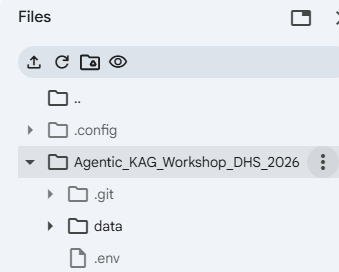

## Credentials & Drivers

### Why are we doing this?
To build our Knowledge Graph, we need two things:
1. A place to store the graph (the **Neo4j Database**).
2. A brain to understand the text (the **OpenAI API**).

This cell loads your secret keys and connection details from a `.env` file so the code can talk to these services securely.

**Logic Flow:**
`Load .env File` -> `Read Database URI/Password` -> `Set OpenAI API Key` -> `Print Confirmation`

In [8]:
import os

os.chdir('/content/Agentic_KAG_Workshop_DHS_2026/')

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    print("error reading env details")
    pass

# --- Neo4j Sandbox ---
NEO4J_URI      = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

# --- OpenAI ---
os.environ.setdefault(
    'OPENAI_API_KEY',
    os.getenv('OPENAI_API_KEY')
)

# --- Google Generative AI ---
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')

print('NEO4J_URI :', NEO4J_URI)
print('OPENAI key set:', bool(os.environ.get('OPENAI_API_KEY')))
print('GOOGLE_API_KEY set:', bool(GOOGLE_API_KEY))

NEO4J_URI : bolt://18.215.15.211
OPENAI key set: True
GOOGLE_API_KEY set: False


In [9]:
openai_key = os.environ.get('OPENAI_API_KEY')
if openai_key:
    print(f"OpenAI API Key successfully loaded (starts with: {openai_key[:4]}...)")
else:
    print("OpenAI API Key not found. Please ensure it's set in your .env file or environment variables.")

OpenAI API Key successfully loaded (starts with: sk-p...)


## Initialize LLM

In [3]:
from neo4j_graphrag.llm import OpenAILLM

# Initialize LLM
llm = OpenAILLM(
    model_name='gpt-5-mini',
)
print('LLM ready ✔')

LLM ready ✔


## ⚖️ Louvain vs. Leiden — Which Algorithm and Why?

Both **Louvain** and **Leiden** are popular community detection algorithms that optimize **modularity** (a score measuring how well nodes are grouped into clusters). In this workshop we use **Leiden**, which is a refined successor to Louvain.

| Aspect | Louvain (2008) | Leiden (2019) ✅ *used here* |
|--------|----------------|------------------------------|
| **Core idea** | Greedily merges nodes to maximize modularity | Same goal, but adds a *refinement* step |
| **Cluster quality** | Can produce **badly connected** or even **disconnected** communities | Guarantees communities are **well-connected** |
| **Stability** | Results can vary more between runs | More **stable and reproducible** |
| **Speed** | Fast | Fast — often **faster** at scale |
| **Availability in GDS** | `gds.louvain.*` | `gds.leiden.*` |

### 🎯 Why Leiden for our Movie Graph?
- It avoids the "broken cluster" problem, so our movie/actor/genre groups stay **meaningful and connected**.
- More stable results mean **reproducible summaries** during a live workshop demo.
- It's a near drop-in replacement — swapping to Louvain later is as easy as changing `gds.leiden.write` to `gds.louvain.write`.

> 💡 **Rule of thumb:** *Start with Leiden.* Only reach for Louvain if you need to reproduce older results or compare algorithms.


## 🎬 Step 2 — Define MovieCommunitySummarizer

The `MovieCommunitySummarizer` class automates the process of finding and describing thematic groups (communities) within a movie knowledge graph. Its core functionalities include:

*   **Graph Projection and Community Detection**: It uses Neo4j's **Graph Data Science (GDS)** library to project the graph into memory and run the **Leiden algorithm** for community detection.
*   **Community Retrieval and Summarization**: Once communities are identified, it retrieves their nodes and relationships, then leverages a **Large Language Model (LLM)** to generate human-readable summaries for each community.
*   **Persistence and Cleanup**: These summaries are then **saved back into Neo4j** as `Community` nodes, and the in-memory GDS projection is dropped to clean up resources.

This pipeline is crucial for enabling **GraphRAG** applications by transforming complex graph data into digestible insights for LLMs, allowing them to reason over high-level themes rather than individual data points.

In [10]:
from neo4j import GraphDatabase

class MovieCommunitySummarizer:
    def __init__(self, driver,llm=None,graph_name='movie_graph'):
        self.driver=driver
        self.llm=llm
        self.graph_name=graph_name

    def project_graph(self):
        # Discover which labels and relationship types ACTUALLY exist in the DB.
        # GDS fails the whole projection if we list a relationship type that isn't
        # present, so we build the projection dynamically from the live schema.
        with self.driver.session() as s:
            labels = [r["label"] for r in s.run("CALL db.labels() YIELD label RETURN label")]
            rel_types = [
                r["relationshipType"]
                for r in s.run(
                    "CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType"
                )
            ]

        # Exclude the :Community label we write later so it doesn't pollute the projection
        labels = [l for l in labels if l != "Community"]

        if not labels or not rel_types:
            raise ValueError(
                "No labels/relationships found to project. "
                "Did you run the sample-data loader (Step 1)?"
            )

        rel_projection = {rt: {"orientation": "UNDIRECTED"} for rt in rel_types}

        with self.driver.session() as s:
            try:
                # yield an explicit column so we don't trigger the deprecated `schema` return
                s.run(
                    "CALL gds.graph.drop($g, false) YIELD graphName RETURN graphName",
                    g=self.graph_name,
                ).consume()
            except Exception:
                pass
            # .consume() forces the projection to actually run before we continue
            s.run(
                "CALL gds.graph.project($graph, $labels, $rels)",
                graph=self.graph_name,
                labels=labels,
                rels=rel_projection,
            ).consume()

        print(f"   Projected labels: {labels}")
        print(f"   Projected relationships: {rel_types}")

    def run_leiden(self):
        # IMPORTANT: consume the result so the write-back actually executes & commits.
        # Without .consume()/.data(), the auto-commit transaction may be discarded
        # before Leiden writes the `community` property -> 0 communities downstream.
        query = """
        CALL gds.leiden.write($g, {writeProperty: 'community'})
        YIELD communityCount, nodePropertiesWritten, modularity
        RETURN communityCount, nodePropertiesWritten, modularity
        """
        with self.driver.session() as s:
            record = s.run(query, g=self.graph_name).single()
        print(
            f"   Leiden wrote 'community' to {record['nodePropertiesWritten']} nodes "
            f"across {record['communityCount']} communities "
            f"(modularity={record['modularity']:.4f})"
        )
        return record

    def get_communities(self, member_limit=60):
        # Return COMPACT community data so we don't blow the LLM token limit.
        # - Only node name/title + primary label (not full properties)
        # - Relationship info as type counts (not every relationship w/ full targets)
        # `member_limit` caps how many member names we keep per community.
        q = '''
MATCH (n)
WHERE n.community IS NOT NULL
WITH n.community AS community,
     collect(DISTINCT coalesce(n.title, n.name, head(labels(n))))[0..$limit] AS members,
     count(DISTINCT n) AS size
RETURN community, members, size
ORDER BY size DESC
'''
        rels_q = '''
MATCH (n)-[r]-(m)
WHERE n.community = $cid AND m.community = $cid
RETURN type(r) AS rel_type, count(DISTINCT r) AS cnt
ORDER BY cnt DESC
'''
        with self.driver.session() as s:
            rows = [x.data() for x in s.run(q, limit=member_limit)]
            for row in rows:
                row['rel_counts'] = {
                    r['rel_type']: r['cnt']
                    for r in s.run(rels_q, cid=row['community'])
                }
        return rows

    async def summarize_community(self, c):
        # Build a compact prompt from the trimmed community data.
        members = c["members"]
        shown = ", ".join(str(m) for m in members)
        more = c["size"] - len(members)
        if more > 0:
            shown += f", ... (+{more} more)"
        rels = ", ".join(f"{k}:{v}" for k, v in c.get("rel_counts", {}).items()) or "none"
        prompt = (
            "You are summarizing a community from a Movie Knowledge Graph.\n"
            f"This community has {c['size']} members.\n"
            f"Relationship types (with counts): {rels}\n"
            f"Sample members: {shown}\n\n"
            "In 2-3 sentences, describe the common theme of this community "
            "(e.g. genre, language/industry, franchise, key people)."
        )
        if self.llm is None:
            return prompt
        result = await self.llm.ainvoke(prompt)
        return result.content if hasattr(result, 'content') else str(result)

    async def summarize_all(self):
        out = []
        for c in self.get_communities():
            out.append((c['community'], await self.summarize_community(c)))
        return out

    def save_summaries(self, summaries):
        # 1) Upsert the Community node with a STABLE, namespaced id plus useful
        #    properties (title, size) — not just the summary.
        #    - id: namespaced (e.g. "movie-community-3") so ids never collide
        #          with other pipelines and MERGE stays idempotent.
        #    - community_no: the raw Leiden integer, used to link members.
        #    - title: a short label derived from the first line/sentence of the summary.
        #    - size: number of member entities in the community.
        # 2) LINK every entity with this community id to the Community node, so the
        #    graph shows edges (entity)-[:IN_COMMUNITY]->(Community).
        upsert_q = '''
MERGE (c:Community {id:$node_id})
SET c.community_no = $cid,
    c.summary = $summary,
    c.title = $title
'''
        link_q = '''
MATCH (c:Community {id:$node_id})
MATCH (n)
WHERE n.community = $cid AND NOT n:Community
WITH c, collect(n) AS members
SET c.size = size(members)
FOREACH (n IN members | MERGE (n)-[:IN_COMMUNITY]->(c))
'''
        with self.driver.session() as s:
            for cid, summary in summaries:
                node_id = f"movie-community-{cid}"
                # Derive a short title from the first sentence/line of the summary.
                title = summary.strip().split("\n")[0].split(". ")[0][:80]
                s.run(upsert_q, node_id=node_id, cid=cid,
                      summary=summary, title=title).consume()
                s.run(link_q, node_id=node_id, cid=cid).consume()
        print(f"   Linked members to {len(summaries)} Community nodes via :IN_COMMUNITY")

    def drop_projection(self):
        with self.driver.session() as s:
            s.run(
                "CALL gds.graph.drop($g, false) YIELD graphName RETURN graphName",
                g=self.graph_name,
            ).consume()


## 🎬 Step 3 — Connect & Load existing Movie Graph

Before we can detect communities, we need a graph to work with. The cell below connects to your existing Neo4j instance using the config above.



In [11]:
from neo4j import GraphDatabase

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

# Verify connectivity
driver.verify_connectivity()
print("✅ Connected to Neo4j at", NEO4J_URI)


✅ Connected to Neo4j at bolt://18.215.15.211


## 🚀 Step 4 — Run the Pipeline End-to-End

Now we put it all together. We'll run each stage and **print the output** so you can *see* what happens at every step:

1. **Project** the graph into GDS.
2. **Run Leiden** to assign community ids.
3. **Retrieve & inspect** the detected communities.
4. **Summarize** each community (LLM optional — runs in prompt-preview mode without one).
5. **Save** summaries back to Neo4j.
6. **Clean up** the in-memory projection.

> 💡 **No LLM configured?** Leave `llm = None`. The summarizer will return the prompt it *would* send — great for understanding the mechanics before adding a real model.


In [12]:
GRAPH_NAME = "MOVIE_GRAPH"

# Optional: quiet the harmless Neo4j notification warnings (property-not-yet-exists,
# deprecated `schema` return from gds.graph.drop). They don't affect the results.
import logging
logging.getLogger("neo4j.notifications").setLevel(logging.ERROR)

summarizer = MovieCommunitySummarizer(driver, llm, graph_name=GRAPH_NAME)

# 1) Project the graph into GDS
summarizer.project_graph()
print("✅ Step 1: Graph projected into GDS as", GRAPH_NAME)

# 2) Run Leiden community detection
summarizer.run_leiden()
print("✅ Step 2: Leiden finished — every node now has a 'community' property\n")

# 3) Retrieve & inspect the communities
communities = summarizer.get_communities()
print(f"🔎 Step 3: Detected {len(communities)} communities (showing largest first)\n")
for c in communities[:10]:
    preview = ", ".join(str(m) for m in c['members'][:8])
    print(f"  Community {c['community']} ({c['size']} members): {preview} ...")
print()

# 4) Summarize each community (LLM optional)
summaries = await summarizer.summarize_all()
print("📝 Step 4: Community summaries\n")
for cid, summary in summaries:
    print(f"--- Community {cid} ---")
    print(summary[:500], "\n")

# 5) Save summaries back to Neo4j as :Community nodes
summarizer.save_summaries(summaries)
print("✅ Step 5: Summaries saved as (:Community) nodes")

# 6) Clean up the in-memory projection
summarizer.drop_projection()
print("✅ Step 6: GDS projection dropped — pipeline complete! 🎉")

   Projected labels: ['__KGBuilder__', '__Entity__', 'Movie', 'Person', 'Genre', 'ProductionCompany', 'Country', 'Language', 'Keyword', 'CastMember', '__Chunk__', '__Community__']
   Projected relationships: ['DIRECTED_BY', 'CAST_IN', 'HAS_GENRE', 'PRODUCED_BY', 'PRODUCED_IN', 'SPOKEN_IN', 'TAGGED_WITH']
✅ Step 1: Graph projected into GDS as MOVIE_GRAPH
   Leiden wrote 'community' to 4918 nodes across 32 communities (modularity=0.5565)
✅ Step 2: Leiden finished — every node now has a 'community' property

🔎 Step 3: Detected 32 communities (showing largest first)

  Community 14 (717 members): Action, Crime, India, Lyca Productions, historical fiction, period drama, history of india, Samuthirakani ...
  Community 3 (709 members): Hindi, Randeep Hooda, Pankaj Tripathi, sequel, romance, drugs, coming of age, Punjabi ...
  Community 18 (622 members): Arabic, Thriller, rescue mission, sacrifice, hunter, tiger, parent child relationship, wrestling ...
  Community 33 (403 members): Brian Tyre

## 🧭 Recap & Ideas for Extension

**What you just did:**
loaded a Movie graph → detected communities with Leiden → summarized each cluster → stored the summaries back in Neo4j. That is a complete **community-based GraphRAG** foundation!

**Try these next:**
- 🔁 Switch `gds.leiden.write` to `gds.louvain.write` and compare the clusters.
- 🏷️ Make node labels and relationship types configurable instead of hard-coded.
- 🧬 Store **summary embeddings** for semantic search over communities.
- 🔎 Build a **Community → Movie** retrieval query for GraphRAG.
- 🖼️ Visualize communities in **Neo4j Bloom** (color by the `community` property).
- 🤖 Feed community summaries into a **GraphRAG prompt** to answer thematic questions.

> 🧹 **Don't forget** to close the driver when you're done: `driver.close()`
